## Connecting to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Checking GPU availability

In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

## Creating project folder in Drive

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/NewsImageCNN', exist_ok=True)
os.makedirs('/content/drive/MyDrive/NewsImageCNN/checkpoints', exist_ok=True)
print("Project folders created in Google Drive!")

Checkpoints are used to:

Store your project files

Save model progress (so you don’t lose training)

## Upload your kaggle.json 
##### (Needed to download datasets from Kaggle)

In [ ]:
from google.colab import files
files.upload()

## Set up Kaggle in Colab

In [ ]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

## Download Intel Image Classification dataset

In [ ]:
os.system('kaggle datasets download -d puneet6060/intel-image-classification')

## Unzipping dataset into folder

In [ ]:
os.system('unzip -q intel-image-classification.zip -d /content/intel_data')
print("Dataset ready!")

## Check folder structure

In [ ]:
for root, dirs, files_list in os.walk('/content/intel_data'):
    level = root.replace('/content/intel_data', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

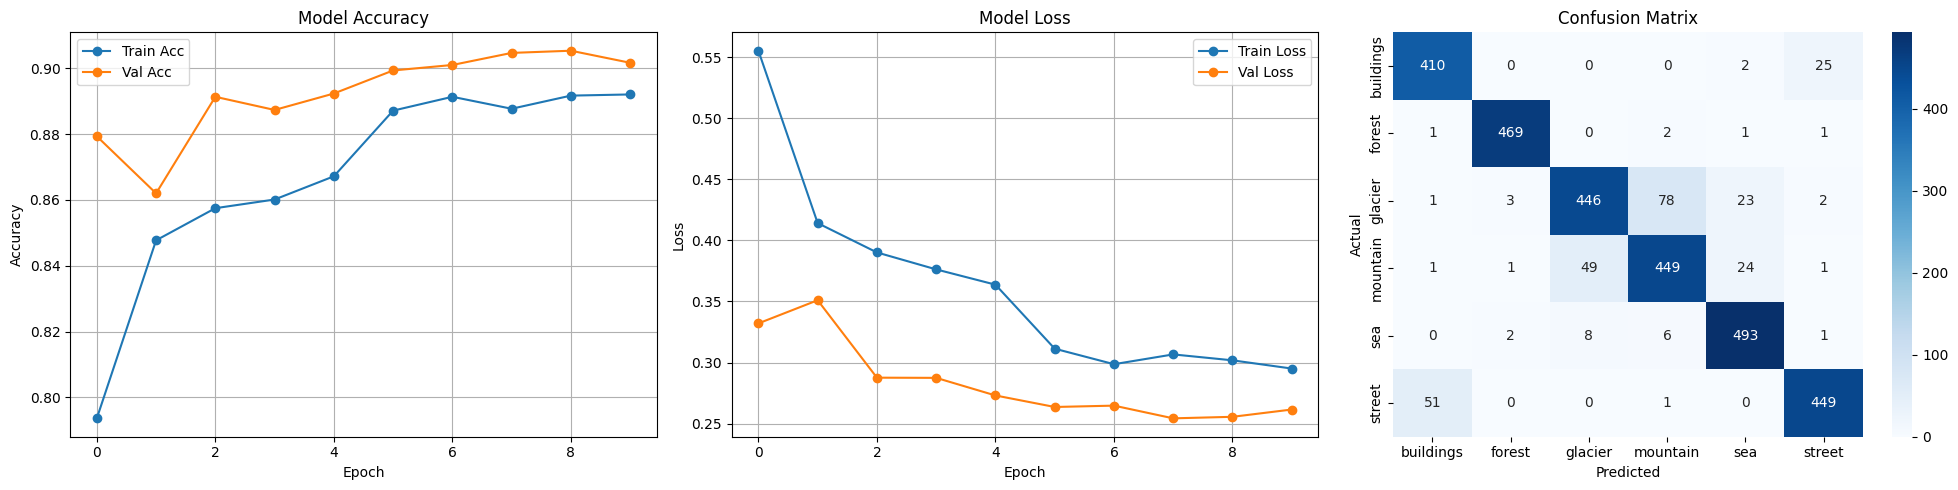

Results saved to Drive!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1 - Accuracy
axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot 2 - Loss
axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Plot 3 - Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NewsImageCNN/results.png', dpi=150)
plt.show()
print("Results saved to Drive!")

In [13]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageTextDataset(Dataset):
    def __init__(self, samples, selected_classes,
                 transform=None, training=False):
        self.samples          = samples
        self.selected_classes = selected_classes
        self.transform        = transform
        self.training         = training

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        cls_name        = self.selected_classes[label]

        # Load image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Generate text description
        if self.training:
            num_words = random.randint(4, 6)
            desc      = generate_random_description(cls_name, num_words)
        else:
            random.seed(idx)
            desc = generate_random_description(cls_name, 5)
            random.seed()

        text_feat = get_text_features(desc).squeeze(0)

        return image, text_feat, label

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Build samples
train_path   = '/content/intel_data/seg_train/seg_train'
val_path     = '/content/intel_data/seg_test/seg_test'
class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}

def build_samples(root_path, class_to_idx):
    samples = []
    for cls, idx in class_to_idx.items():
        cls_path = os.path.join(root_path, cls)
        if not os.path.exists(cls_path):
            print(f"Missing: {cls}")
            continue
        for img_file in os.listdir(cls_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                samples.append((os.path.join(cls_path, img_file), idx))
    return samples

train_samples = build_samples(train_path, class_to_idx)
val_samples   = build_samples(val_path,   class_to_idx)

print(f"Train samples: {len(train_samples)}")
print(f"Val samples  : {len(val_samples)}")

# Datasets
train_dataset = ImageTextDataset(train_samples, selected_classes,
                                  train_transforms, training=True)
val_dataset   = ImageTextDataset(val_samples,   selected_classes,
                                  val_transforms,   training=False)

# ✅ num_workers=0 because of dynamic BERT calls
train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train samples: 14034
Val samples  : 3000

Train batches: 439
Val batches  : 94


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, image_text_model.parameters()),
    lr=0.0001
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}

best_val_acc    = 0.0
EPOCHS          = 3
checkpoint_path = '/content/drive/MyDrive/NewsImageCNN/checkpoints/image_text_best.pth'

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    for phase in ['train', 'val']:
        if phase == 'train':
            image_text_model.train()
            loader = train_loader
        else:
            image_text_model.eval()
            loader = val_loader

        running_loss     = 0.0
        running_corrects = 0

        for images, text_feats, labels in loader:
            images     = images.to(device)
            text_feats = text_feats.to(device)
            labels     = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs  = image_text_model(images, text_feats)
                loss     = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss     += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_corrects.double() / len(loader.dataset)

        print(f"{phase.upper()} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            if epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                torch.save(image_text_model.state_dict(), checkpoint_path)
                print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")

print(f"\nTraining Complete! Best Val Acc: {best_val_acc:.4f}")


Epoch 1/3
----------------------------------------
TRAIN — Loss: 0.3349  Acc: 0.8962
VAL — Loss: 0.0717  Acc: 0.9757
  ✅ Best model saved! Val Acc: 0.9757

Epoch 2/3
----------------------------------------
TRAIN — Loss: 0.0763  Acc: 0.9776
VAL — Loss: 0.0409  Acc: 0.9837
  ✅ Best model saved! Val Acc: 0.9837

Epoch 3/3
----------------------------------------
TRAIN — Loss: 0.0440  Acc: 0.9867
VAL — Loss: 0.0285  Acc: 0.9900
  ✅ Best model saved! Val Acc: 0.9900

Training Complete! Best Val Acc: 0.9900


Classification Report:
              precision    recall  f1-score   support

   buildings       0.99      1.00      0.99       437
      forest       0.99      1.00      0.99       474
     glacier       0.98      0.99      0.98       553
    mountain       0.99      0.97      0.98       525
         sea       0.99      1.00      1.00       510
      street       0.99      0.99      0.99       501

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



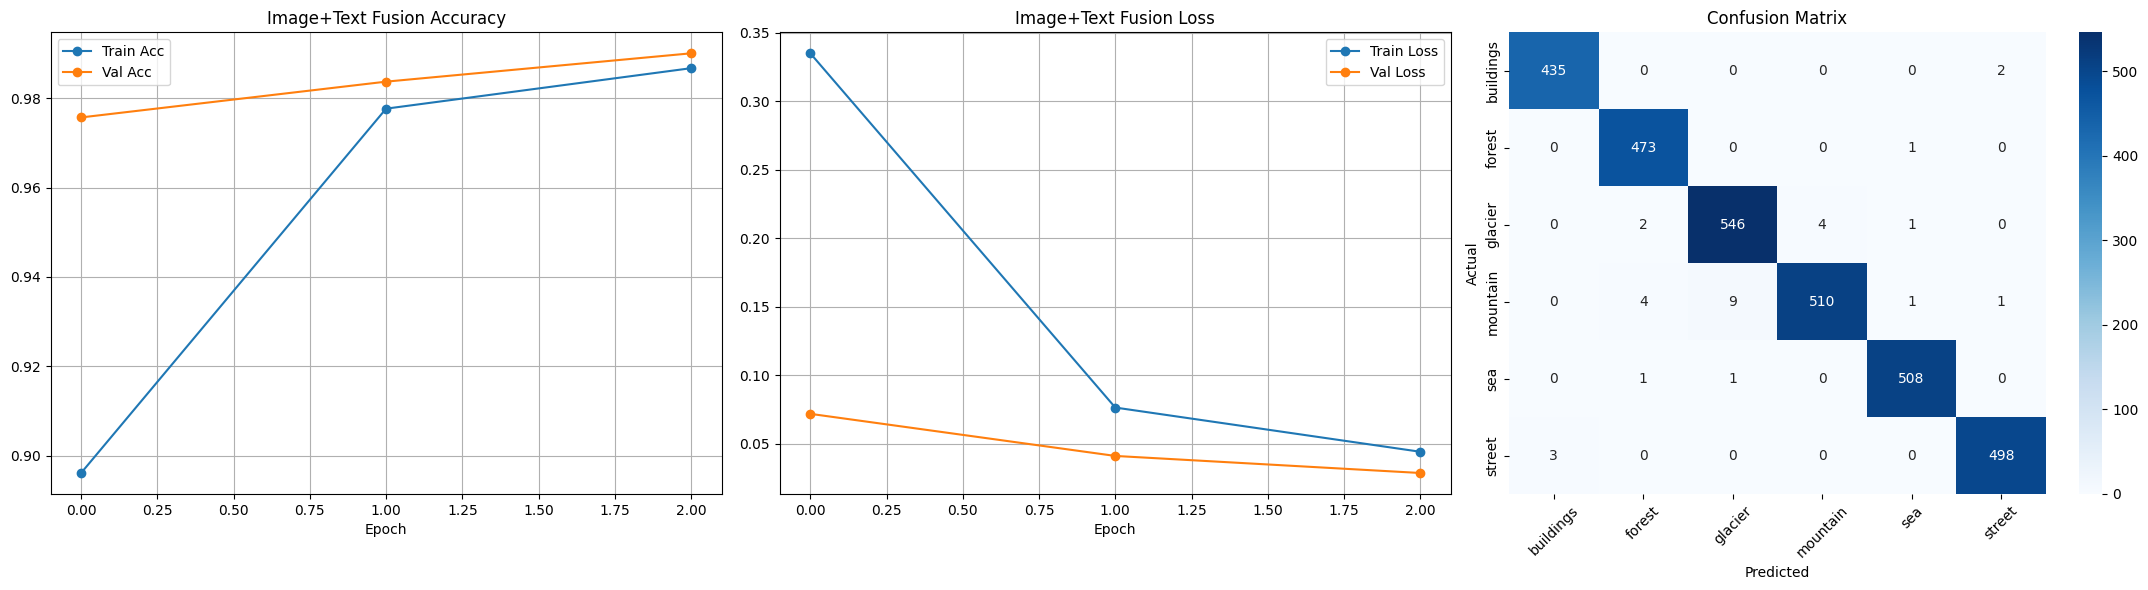

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
image_text_model.load_state_dict(torch.load(checkpoint_path))
image_text_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, text_feats, labels in val_loader:
        images     = images.to(device)
        text_feats = text_feats.to(device)
        outputs    = image_text_model(images, text_feats)
        _, preds   = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=selected_classes))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('Image+Text Fusion Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('Image+Text Fusion Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_classes,
            yticklabels=selected_classes, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NewsImageCNN/image_text_results.png', dpi=150)
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from transformers import DistilBertTokenizer, DistilBertModel
from PIL import Image
import gradio as gr
import pandas as pd
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

selected_classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# ✅ Redefine model
class ImageTextFusionModel(nn.Module):
    def __init__(self, num_classes=6):
        super(ImageTextFusionModel, self).__init__()

        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])

        self.visual_projector = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.text_projector = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.fusion = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, text_feat):
        cnn_out     = self.cnn(image)
        cnn_out     = cnn_out.view(cnn_out.size(0), -1)
        visual_feat = self.visual_projector(cnn_out)

        if text_feat.dim() == 3:
            text_feat = text_feat.squeeze(1)
        text_feat = self.text_projector(text_feat)

        fused = torch.cat([visual_feat, text_feat], dim=1)
        out   = self.fusion(fused)
        return out

# ✅ Load DistilBERT
tokenizer  = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert_model = bert_model.to(device)
bert_model

Device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [17]:
# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(image, description):
    try:
        # --- Prepare image ---
        if image is None:
            return "❌ Please upload an image", pd.DataFrame()

        # Convert to PIL if needed
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)

        image        = image.convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        # --- Prepare text ---
        if not description or description.strip() == "":
            description = "outdoor natural scene landscape view"

        text_feat = get_text_features(description)
        if text_feat.dim() == 3:
            text_feat = text_feat.squeeze(1)
        text_feat = text_feat.to(device)

        # --- Predict ---
        with torch.no_grad():
            output = image_text_model(image_tensor, text_feat)
            probs  = F.softmax(output, dim=1)[0]

        confidence, pred_idx = torch.max(probs, 0)
        predicted_class      = selected_classes[pred_idx.item()]
        confidence_pct       = confidence.item() * 100

        # --- Build results dataframe ---
        df = pd.DataFrame({
            "Class"           : selected_classes,
            "Probability (%)" : [round(float(probs[i].item()) * 100, 2)
                                 for i in range(len(selected_classes))]
        })
        # Sort by probability
        df = df.sort_values("Probability (%)", ascending=False).reset_index(drop=True)

        result = f"🎯 Predicted: {predicted_class.upper()}\n📊 Confidence: {confidence_pct:.2f}%"
        return result, df

    except Exception as e:
        return f"❌ Error: {str(e)}", pd.DataFrame()

In [18]:
css = """
    .gradio-container {
        font-family: 'Arial', sans-serif;
    }
"""

with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo_image:

    gr.Markdown("""
    # 🖼️ Deep Learning News Image Content Recognition
    ### Multimodal Fusion — ResNet50 CNN + DistilBERT
    Upload an image and optionally provide a text description
    to classify the content using multimodal deep learning.
    """)

    with gr.Row():

        # Left column — inputs
        with gr.Column(scale=1):
            image_input = gr.Image(
                label  = "📷 Upload Image",
                height = 300
            )
            text_input = gr.Textbox(
                label       = "📝 Image Description (optional)",
                placeholder = "e.g. tall buildings in city urban area",
                lines       = 2
            )
            predict_btn = gr.Button(
                "🔍 Predict",
                variant = "primary",
                size    = "lg"
            )

        # Right column — outputs
        with gr.Column(scale=1):
            result_output = gr.Textbox(
                label       = "🎯 Prediction Result",
                lines       = 3,
                interactive = False
            )
            prob_output = gr.BarPlot(
                x       = "Class",
                y       = "Probability (%)",
                title   = "📊 Class Probabilities",
                tooltip = ["Class", "Probability (%)"],
                y_lim   = [0, 100],
                label   = "📊 Class Probabilities"
            )

    # Supported classes
    gr.Markdown("### 📌 Supported Classes")
    gr.Markdown("""
    `buildings` • `forest` • `glacier` • `mountain` • `sea` • `street`
    """)

    # Example images
    gr.Markdown("### 🖼️ Try Example Descriptions")
    gr.Markdown("""
    - buildings → *"tall urban skyscraper city architecture"*
    - forest    → *"dense green trees woodland nature"*
    - glacier   → *"ice frozen cold arctic snow"*
    - mountain  → *"rocky peak summit highland steep"*
    - sea       → *"ocean waves beach coastal marine"*
    - street    → *"road traffic urban sidewalk lane"*
    """)

    predict_btn.click(
        fn      = predict_image,
        inputs  = [image_input, text_input],
        outputs = [result_output, prob_output]
    )

print("Gradio Image app ready!")

/tmp/ipykernel_5114/3998032780.py:7: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo_image:
/tmp/ipykernel_5114/3998032780.py:7: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo_image:


Gradio Image app ready!


In [19]:
demo_image.launch(
    share      = True,
    debug      = True,
    show_error = True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3f0b37bb4f6817b4b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3f0b37bb4f6817b4b6.gradio.live
